# EEG Moter Imagery Dataset Exploration

## Goal
To understand the EEG Motor Imagery dataset before performing any preprocessing or machine learning. 

In this notebook, I will:
- Learn what motor imagery is
- Download the dataset
- Load one subject
- Explore the recording
- Visualize the EEg

In [1]:
import mne
import numpy as np
import matplotlib.pyplot as plt

print(f"MNE version: {mne.__version__}")

MNE version: 1.12.1


## What is Motor Imagery?

Motor imagery is the mental simulation of movement without actually moving the body.

Brain-computer interfaces can decoded these imagined movements from EEG signals, allowing users to control external devices. 

In [9]:
raw = mne.io.read_raw_edf("../data/S001R06.edf", preload=True)
print(raw)

Extracting EDF parameters from ../data/S001R06.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
<RawEDF | S001R06.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>


In [10]:
from mne.datasets import eegbci

subject = 1
runs = [6, 10, 14]

files = eegbci.load_data(subject, runs)

print(files)

[PosixPath('/Users/ceciliajia/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R06.edf'), PosixPath('/Users/ceciliajia/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R10.edf'), PosixPath('/Users/ceciliajia/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R14.edf')]


In [11]:
import numpy as np
print(np.__version__)

import mne
raw = mne.io.read_raw_edf("../data/S001R06.edf", preload=True)
print(raw)

2.4.6
Extracting EDF parameters from ../data/S001R06.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
<RawEDF | S001R06.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>


In [12]:
import numpy as np
import mne

print(np.__version__)
print(mne.__version__)

raw = mne.io.read_raw_edf("../data/S001R06.edf", preload=True)
print(raw)

2.4.6
1.12.1
Extracting EDF parameters from ../data/S001R06.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
<RawEDF | S001R06.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>


In [13]:
print(raw.info)

<Info | 8 non-empty values
 bads: []
 ch_names: Fc5., Fc3., Fc1., Fcz., Fc2., Fc4., Fc6., C5.., C3.., C1.., ...
 chs: 64 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: 2009-08-12 16:15:00 UTC
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: X>
>


In [14]:
raw.ch_names

['Fc5.',
 'Fc3.',
 'Fc1.',
 'Fcz.',
 'Fc2.',
 'Fc4.',
 'Fc6.',
 'C5..',
 'C3..',
 'C1..',
 'Cz..',
 'C2..',
 'C4..',
 'C6..',
 'Cp5.',
 'Cp3.',
 'Cp1.',
 'Cpz.',
 'Cp2.',
 'Cp4.',
 'Cp6.',
 'Fp1.',
 'Fpz.',
 'Fp2.',
 'Af7.',
 'Af3.',
 'Afz.',
 'Af4.',
 'Af8.',
 'F7..',
 'F5..',
 'F3..',
 'F1..',
 'Fz..',
 'F2..',
 'F4..',
 'F6..',
 'F8..',
 'Ft7.',
 'Ft8.',
 'T7..',
 'T8..',
 'T9..',
 'T10.',
 'Tp7.',
 'Tp8.',
 'P7..',
 'P5..',
 'P3..',
 'P1..',
 'Pz..',
 'P2..',
 'P4..',
 'P6..',
 'P8..',
 'Po7.',
 'Po3.',
 'Poz.',
 'Po4.',
 'Po8.',
 'O1..',
 'Oz..',
 'O2..',
 'Iz..']

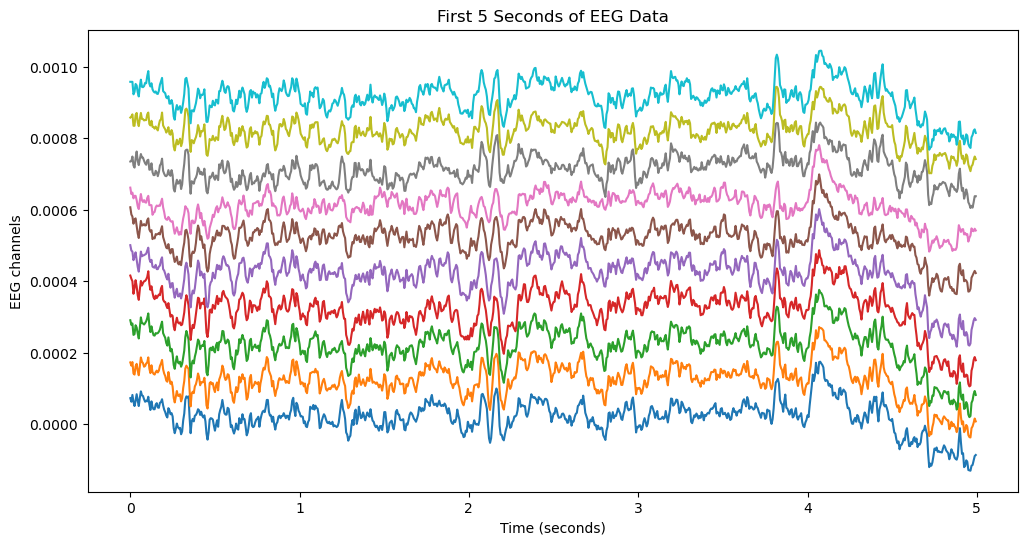

In [16]:
import matplotlib.pyplot as plt

data, times = raw[:10, :800]

plt.figure(figsize=(12, 6))

for i in range(10):
    plt.plot(times, data[i] + i * 0.0001)

plt.xlabel("Time (seconds)")
plt.ylabel("EEG channels")
plt.title("First 5 Seconds of EEG Data")
plt.show()

In [17]:
plt.savefig("../figures/raw_eeg_subject1.png", dpi=300)

<Figure size 640x480 with 0 Axes>

In [18]:
print(raw.info)

<Info | 8 non-empty values
 bads: []
 ch_names: Fc5., Fc3., Fc1., Fcz., Fc2., Fc4., Fc6., C5.., C3.., C1.., ...
 chs: 64 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: 2009-08-12 16:15:00 UTC
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: X>
>


## Recording Metadata

This recording contains 64 EEG channels sampled at 160 Hz. The raw data has a high-pass setting of 0 Hz and a low-pass setting of 80 Hz, meaning the file contains low-frequency drift as well as EEG activity up to 80 Hz. No bad channels are currently marked.

In [19]:
raw.ch_names

['Fc5.',
 'Fc3.',
 'Fc1.',
 'Fcz.',
 'Fc2.',
 'Fc4.',
 'Fc6.',
 'C5..',
 'C3..',
 'C1..',
 'Cz..',
 'C2..',
 'C4..',
 'C6..',
 'Cp5.',
 'Cp3.',
 'Cp1.',
 'Cpz.',
 'Cp2.',
 'Cp4.',
 'Cp6.',
 'Fp1.',
 'Fpz.',
 'Fp2.',
 'Af7.',
 'Af3.',
 'Afz.',
 'Af4.',
 'Af8.',
 'F7..',
 'F5..',
 'F3..',
 'F1..',
 'Fz..',
 'F2..',
 'F4..',
 'F6..',
 'F8..',
 'Ft7.',
 'Ft8.',
 'T7..',
 'T8..',
 'T9..',
 'T10.',
 'Tp7.',
 'Tp8.',
 'P7..',
 'P5..',
 'P3..',
 'P1..',
 'Pz..',
 'P2..',
 'P4..',
 'P6..',
 'P8..',
 'Po7.',
 'Po3.',
 'Poz.',
 'Po4.',
 'Po8.',
 'O1..',
 'Oz..',
 'O2..',
 'Iz..']

In [20]:
data = raw.get_data()

print("Shape:", data.shape)
print("Mean:", data.mean())
print("Standard deviation:", data.std())

Shape: (64, 20000)
Mean: 6.5856453124999995e-06
Standard deviation: 6.750561395084447e-05


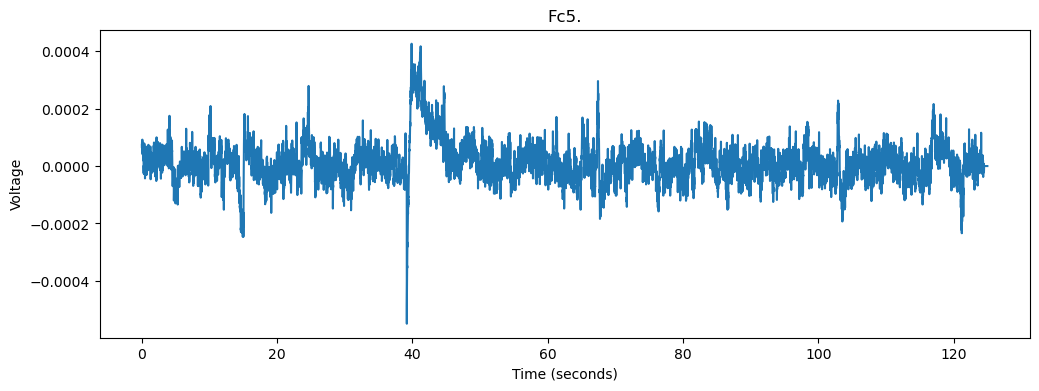

In [21]:
import matplotlib.pyplot as plt

channel = 0

plt.figure(figsize=(12,4))
plt.plot(raw.times, data[channel])
plt.title(raw.ch_names[channel])
plt.xlabel("Time (seconds)")
plt.ylabel("Voltage")
plt.show()

In [22]:
print(raw.ch_names)

['Fc5.', 'Fc3.', 'Fc1.', 'Fcz.', 'Fc2.', 'Fc4.', 'Fc6.', 'C5..', 'C3..', 'C1..', 'Cz..', 'C2..', 'C4..', 'C6..', 'Cp5.', 'Cp3.', 'Cp1.', 'Cpz.', 'Cp2.', 'Cp4.', 'Cp6.', 'Fp1.', 'Fpz.', 'Fp2.', 'Af7.', 'Af3.', 'Afz.', 'Af4.', 'Af8.', 'F7..', 'F5..', 'F3..', 'F1..', 'Fz..', 'F2..', 'F4..', 'F6..', 'F8..', 'Ft7.', 'Ft8.', 'T7..', 'T8..', 'T9..', 'T10.', 'Tp7.', 'Tp8.', 'P7..', 'P5..', 'P3..', 'P1..', 'Pz..', 'P2..', 'P4..', 'P6..', 'P8..', 'Po7.', 'Po3.', 'Poz.', 'Po4.', 'Po8.', 'O1..', 'Oz..', 'O2..', 'Iz..']


In [23]:
print("Shape:", data.shape)

Shape: (64, 20000)


In [24]:
print("Duration (seconds):", raw.times[-1])

Duration (seconds): 124.99375


In [25]:
print("Sampling frequency:", raw.info["sfreq"])

Sampling frequency: 160.0


## Initial Observations

- The recording contains 64 EEG channels
- Signals fluctuate around zero with varying amplitudes
- A large transient artifact appears around 40 seconds
- The recording lasts approximately 125 seconds
- The sampling frequency is 160 Hz